# Lecture 13 (B12): Surrogates and Gaussian processes

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §9.1-9.2 (Deep surrogates), §9.3-9.6 (GPs and Bayesian active learning), §9.7 (Active subspaces), §9.8 (GP value-function iteration), §9.9 (Deep kernels), §9.10 (GPs among Bayesian cousins)  
**Notebook role:** core  
**Original live-course source:** `lectures/day7/code/04_GP_Value_Function_Iteration.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Notebook 4: GP-Based Value Function Iteration

*Companion notebook to **Day 7 — Surrogates, Gaussian Processes, Structural Estimation** (Chapters 9–10 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

## Stochastic Optimal Growth (Brock--Mirman) with Gaussian Process Surrogates

**Course:** Deep Learning in Economics and Finance  
**Reference:** Scheidegger & Bilionis (2019), *"Machine Learning for High-Dimensional Dynamic Stochastic Economies"*, Journal of Computational Science 33, 68--82.

---

### Overview

This notebook implements **Value Function Iteration (VFI)** for the classical one-dimensional **stochastic optimal growth model** (Brock--Mirman), replacing the usual grid-based interpolation with a **Gaussian Process (GP) surrogate**.

The key idea — drawn from the *Adaptive Sparse Grid Gaussian Process (ASGP)* framework of Scheidegger & Bilionis (2019) — is:

1. Evaluate the Bellman operator at a small set of **training points** in the state space.
2. Fit a GP surrogate to those evaluations, obtaining a **probabilistic approximation** of the value function that comes with built-in **uncertainty quantification (UQ)**.
3. Use the GP surrogate as the continuation-value function inside the next Bellman step.
4. Iterate until convergence.

In higher dimensions the training points would live on an **adaptive sparse grid**; here, in 1-D, we use a simple uniform grid to keep things transparent. Even with as few as 15 training points the GP recovers the value function accurately.

**Runtime note:** VFI converges at rate $\beta = 0.96$ per iteration (contraction mapping), so roughly 200 iterations are needed for $\varepsilon = 10^{-4}$. To keep runtime under 60 seconds we optimize GP kernel hyperparameters only during the first 20 iterations and re-use the learned kernel thereafter.

In [1]:
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.special import roots_hermite
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
import matplotlib.pyplot as plt
import warnings

# Suppress sklearn convergence warnings during GP fitting
warnings.filterwarnings("ignore", category=Warning, module="sklearn")

plt.rcParams['font.size'] = 13
np.random.seed(42)

print("All imports successful.")

All imports successful.


## 1. Model Description

We consider the **infinite-horizon, discrete-time stochastic optimal growth model** (Brock & Mirman, 1972).

### Primitives

| Symbol | Meaning | Value |
|--------|---------|-------|
| $\alpha$ | Capital share | 0.36 |
| $\beta$ | Discount factor | 0.96 |
| $\delta$ | Depreciation rate | 0.10 |
| $A$ | TFP level | 1.0 |
| $\sigma$ | Std. dev. of log-TFP shock | 0.04 |

### Bellman Equation

$$
V(k) \;=\; \max_{c \,\ge\, 0} \left\{ \log(c) \;+\; \beta\, \mathbb{E}_z\!\left[ V\!\left(k'\right) \right] \right\}
$$

subject to the **capital accumulation** constraint:

$$
k' \;=\; (1-\delta)\,k \;+\; z\,A\,k^{\alpha} \;-\; c, \qquad k' \ge 0
$$

where $z \sim \text{LogNormal}(0, \sigma^2)$ is an i.i.d. TFP shock, and the **production function** is Cobb--Douglas:

$$
f(k) = A\,k^{\alpha}.
$$

### Utility

We use **log utility** ($\text{CRRA}$ with $\gamma = 1$):

$$
u(c) = \log(c).
$$

### Expectation via Gauss--Hermite Quadrature

Because $z = e^{\sigma \epsilon}$ with $\epsilon \sim \mathcal{N}(0,1)$, we approximate

$$
\mathbb{E}_z\!\left[ V(k') \right] \;\approx\; \frac{1}{\sqrt{\pi}} \sum_{j=1}^{Q} w_j \; V\!\Big( (1-\delta)k + e^{\sigma \sqrt{2}\, x_j} A k^{\alpha} - c \Big)
$$

where $(x_j, w_j)$ are the $Q$-point Gauss--Hermite nodes and weights.

In [2]:
# ── Model parameters ─────────────────────────────────────────────────────────
alpha = 0.36        # Capital share in Cobb-Douglas production
beta  = 0.96        # Discount factor
delta = 0.10        # Capital depreciation rate
A     = 1.0         # Total factor productivity (TFP) level
sigma = 0.04        # Std. dev. of log-TFP shock  (z = exp(sigma * eps))

# ── State-space bounds ───────────────────────────────────────────────────────
k_min = 0.2         # Lower bound on capital
k_max = 3.0         # Upper bound on capital

# ── Training / algorithmic settings ──────────────────────────────────────────
# Classroom setting: 15 training points, 200 max iterations
# Production setting: 50+ training points, 500+ iterations
n_train  = 15       # Number of training points per VFI iteration
max_iter = 200      # Maximum VFI iterations
tol      = 1e-4     # Convergence tolerance (relative sup-norm)

# ── Gauss-Hermite quadrature for E_z[V(k')] ─────────────────────────────────
n_quad = 5          # Number of quadrature nodes
gh_nodes, gh_weights = roots_hermite(n_quad)

# Transform: z_j = exp(sigma * sqrt(2) * x_j), weight = w_j / sqrt(pi)
z_nodes   = np.exp(sigma * np.sqrt(2.0) * gh_nodes)
z_weights = gh_weights / np.sqrt(np.pi)

print(f"Quadrature nodes  (z): {z_nodes}")
print(f"Quadrature weights   : {z_weights}")
print(f"Sum of weights       : {z_weights.sum():.6f}  (should be 1.0)")
print(f"E[z]                 : {(z_weights * z_nodes).sum():.6f}  (should be ~1.0)")

Quadrature nodes  (z): [0.89200923 0.94721891 1.         1.05572216 1.12106463]
Quadrature weights   : [0.01125741 0.22207592 0.53333333 0.22207592 0.01125741]
Sum of weights       : 1.000000  (should be 1.0)
E[z]                 : 1.000800  (should be ~1.0)


## 2. Initial Guess for the Value Function

We need an initial guess $V^{0}(k)$ to start the iteration. A natural choice is the value that a household would obtain if it consumed the **deterministic steady-state output** every period:

$$
V^{0}(k) \;=\; \frac{\log\!\big(A\,k^{\alpha}\big)}{1 - \beta}.
$$

This is *not* the true value function, but it has the right qualitative shape (concave, increasing) and puts us in the right ballpark, so VFI converges quickly.

In [3]:
def V0(k):
    """Initial guess: discounted present value of consuming steady-state output."""
    return np.log(A * k**alpha) / (1.0 - beta)

# Quick sanity check
k_test = np.linspace(k_min, k_max, 5)
print("k        V0(k)")
print("-" * 25)
for k in k_test:
    print(f"{k:.2f}    {V0(k):.4f}")

k        V0(k)
-------------------------
0.20    -14.4849
0.90    -0.9482
1.60    4.2300
2.30    7.4962
3.00    9.8875


## 3. The Bellman Operator

At each training point $k_i$ we solve the **one-dimensional optimization problem**:

$$
V^{\text{new}}(k_i) \;=\; \max_{0 < c < c_{\max}} \left\{ \log(c) \;+\; \beta \sum_{j=1}^{Q} w_j \; V_{\text{GP}}\!\Big( (1-\delta)\,k_i + z_j\, A\, k_i^{\alpha} - c \Big) \right\}
$$

where $c_{\max}$ is the maximum feasible consumption (all available resources minus a small safety buffer so that $k' > 0$), and $V_{\text{GP}}$ is the GP surrogate from the previous iteration.

We implement two functions:

- **`bellman_rhs`**: evaluates the *negative* of the Bellman RHS for a given $(c, k)$ (negative because `scipy.optimize.minimize_scalar` minimizes).
- **`solve_bellman_point`**: finds the optimal $c^*(k)$ and returns the maximized value $V^{\text{new}}(k)$ together with $c^*(k)$.

In [4]:
def bellman_rhs(c, k, V_gp, z_nodes, z_weights):
    """
    Compute the *negative* RHS of the Bellman equation (for minimization).

    Parameters
    ----------
    c : float
        Consumption.
    k : float
        Current capital.
    V_gp : GaussianProcessRegressor or callable
        GP surrogate (or any callable) for the continuation value.
    z_nodes : ndarray
        Quadrature TFP shock realizations.
    z_weights : ndarray
        Corresponding quadrature weights (summing to 1).

    Returns
    -------
    float
        Negative of  log(c) + beta * E[V(k')].
    """
    if c <= 0:
        return 1e10  # infeasible

    # Capital next period for each shock realization
    k_next = (1.0 - delta) * k + z_nodes * A * k**alpha - c

    # All k_next must be positive; penalize if not
    if np.any(k_next <= 0):
        return 1e10

    # Clip k_next to the domain of the GP (extrapolation can be wild)
    k_next_clipped = np.clip(k_next, k_min, k_max)

    # Evaluate continuation value via the GP surrogate
    V_next = V_gp(k_next_clipped.reshape(-1, 1)) if callable(V_gp) else \
             V_gp.predict(k_next_clipped.reshape(-1, 1))

    # Expected continuation value
    EV = np.dot(z_weights, V_next.ravel())

    return -(np.log(c) + beta * EV)


def solve_bellman_point(k, V_gp, z_nodes, z_weights):
    """
    Solve the Bellman equation at a single capital level k.

    Returns
    -------
    V_new : float
        Maximized value V(k).
    c_star : float
        Optimal consumption.
    """
    # Maximum feasible consumption: can eat almost all available resources
    # Use the *worst-case* (lowest) TFP shock to ensure k' > 0
    z_min = z_nodes.min()
    c_max = (1.0 - delta) * k + z_min * A * k**alpha - k_min * 0.5
    c_max = max(c_max, 1e-8)

    # A small lower bound on consumption
    c_low = 1e-8

    result = minimize_scalar(
        bellman_rhs,
        bounds=(c_low, c_max),
        args=(k, V_gp, z_nodes, z_weights),
        method='bounded',
        options={'xatol': 1e-10}
    )

    c_star = result.x
    V_new  = -result.fun  # flip sign back
    return V_new, c_star

print("Bellman operator functions defined.")

Bellman operator functions defined.


## 4. GP Surrogate Construction & VFI Loop

This is the core of the algorithm, following **Algorithm 1** from Scheidegger & Bilionis (2019):

1. **Initialize**: build a GP from the initial guess $V^0$ evaluated on training points.
2. **Iterate**:
   - Generate $n$ training points $\{k_1, \ldots, k_n\}$ in $[k_{\min}, k_{\max}]$.
   - At each $k_i$, solve the Bellman equation using the *current* GP as the continuation-value function.
   - Fit a *new* GP to the updated training data $\{(k_i, V^{\text{new}}_i)\}$.
   - Compute the convergence error:
     $$
     \text{err} = \frac{\max_i |V^{\text{new}}_i - V^{\text{old}}_i|}{\max_i V^{\text{old}}_i - \min_i V^{\text{old}}_i}
     $$
   - If $\text{err} < \text{tol}$, stop.
3. Return the converged GP surrogate $V_{\text{GP}}^*$.

**GP kernel**: We use $\texttt{ConstantKernel} \times \texttt{RBF}$ with a small fixed nugget ($\alpha = 10^{-8}$) for numerical stability. Since the Bellman evaluations are deterministic (no observation noise), we omit a $\texttt{WhiteKernel}$ to prevent the GP from re-learning a spurious noise level at each iteration, which can destabilize convergence.

In [5]:
def build_gp(k_train, V_train, kernel=None):
    """
    Fit a Gaussian Process regressor to (k_train, V_train).

    Kernel: ConstantKernel * RBF  (with a small fixed nugget alpha for stability).
    We avoid WhiteKernel here because the Bellman evaluations are deterministic
    (no observation noise), and letting the GP re-learn a noise level each
    iteration can cause oscillations in the VFI loop.

    Parameters
    ----------
    kernel : sklearn kernel or None
        If provided, use this kernel with fixed hyperparameters (no optimization).
        If None, create a new kernel and optimize hyperparameters.
    """
    if kernel is not None:
        # Re-use learned hyperparameters, skip optimization (fast)
        gp = GaussianProcessRegressor(
            kernel=kernel,
            optimizer=None,       # do not re-optimize
            normalize_y=True,
            alpha=1e-8
        )
    else:
        # Fresh kernel, optimize hyperparameters
        kernel_new = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
        gp = GaussianProcessRegressor(
            kernel=kernel_new,
            n_restarts_optimizer=3,
            normalize_y=True,
            alpha=1e-8
        )

    gp.fit(k_train.reshape(-1, 1), V_train)
    return gp


# Training points (fixed uniform grid)
k_train = np.linspace(k_min, k_max, n_train)

# Initialize: evaluate V0 at training points
V_old = np.array([V0(k) for k in k_train])

# Build initial GP from V0
gp_current = build_gp(k_train, V_old)

# VFI loop
# We optimize GP hyperparameters for the first 20 iterations; after that,
# the kernel has settled and we re-use the learned hyperparameters for speed.
HP_OPT_ITERS = 20

error_history = []
V_history     = [V_old.copy()]

print(f"{'Iter':>4s}  {'Sup-norm error':>14s}  {'Status':>10s}")
print("-" * 35)

for it in range(1, max_iter + 1):
    V_new = np.zeros(n_train)
    c_opt = np.zeros(n_train)

    # Step 1: Evaluate Bellman operator at each training point
    for i, k in enumerate(k_train):
        V_new[i], c_opt[i] = solve_bellman_point(k, gp_current, z_nodes, z_weights)

    # Step 2: Compute convergence error (relative sup-norm)
    V_range = V_old.max() - V_old.min()
    if V_range < 1e-12:
        V_range = 1.0  # avoid division by zero on first iteration
    err = np.max(np.abs(V_new - V_old)) / V_range
    error_history.append(err)

    # Step 3: Fit new GP to updated values
    # After HP_OPT_ITERS, re-use the learned kernel to skip optimization
    if it <= HP_OPT_ITERS:
        gp_current = build_gp(k_train, V_new, kernel=None)
    else:
        gp_current = build_gp(k_train, V_new, kernel=gp_current.kernel_)

    # Store and report
    V_history.append(V_new.copy())
    converged = err < tol
    status = "CONVERGED" if converged else ""

    # Print every 10 iterations, plus the first 3 and any converged iteration
    if it <= 3 or it % 10 == 0 or converged:
        print(f"{it:4d}  {err:14.6e}  {status:>10s}")

    V_old = V_new.copy()

    if converged:
        print(f"\n[OK] Converged after {it} iterations (error = {err:.2e}).")
        break
else:
    print(f"\n[WARN] Did not converge after {max_iter} iterations (error = {err:.2e}).")

Iter  Sup-norm error      Status
-----------------------------------


   1    3.435046e-01            


   2    2.563416e-01            


   3    1.980654e-01            


  10    2.825249e-02            


...

 110    4.787713e-04            


 120    3.183028e-04            


 130    2.116181e-04            


 140    1.406906e-04            


 149    9.743303e-05   CONVERGED

[OK] Converged after 149 iterations (error = 9.74e-05).


## 5. Convergence Diagnostics

The plot below shows the **relative sup-norm error** across VFI iterations on a log scale. Because the Bellman operator is a contraction mapping (with modulus $\beta = 0.96$), we expect roughly geometric (linear on a log scale) convergence.

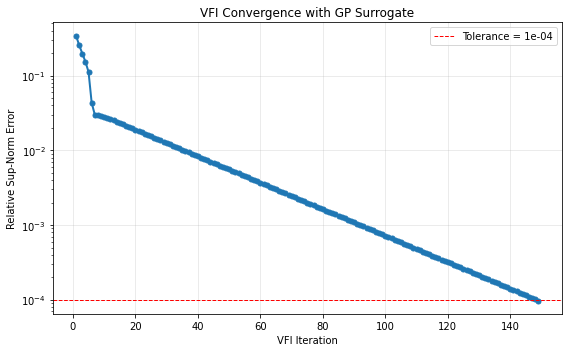

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(range(1, len(error_history) + 1), error_history, 'o-', linewidth=2, markersize=5)
ax.axhline(tol, color='r', linestyle='--', linewidth=1, label=f'Tolerance = {tol:.0e}')
ax.set_xlabel('VFI Iteration')
ax.set_ylabel('Relative Sup-Norm Error')
ax.set_title('VFI Convergence with GP Surrogate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_cell_12.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Value Function with Uncertainty Bands

A key advantage of the GP surrogate over deterministic interpolation is that it provides **posterior uncertainty estimates**. Below we plot the converged value function $V(k)$ evaluated on a fine grid, together with the **95% confidence interval** (mean $\pm\, 1.96\,\sigma$). The training points are shown as dots.

Because we use only 15 training points, the GP nonetheless delivers a smooth, accurate approximation with tight uncertainty bands throughout the domain.

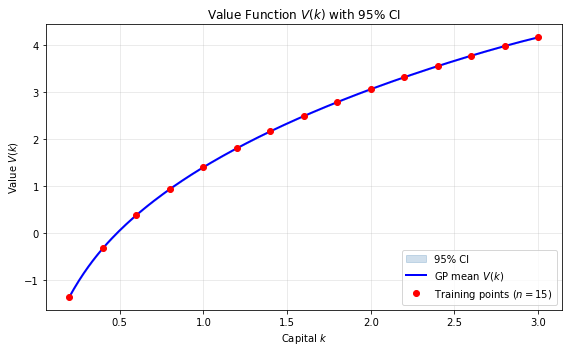

In [7]:
# Evaluate the converged GP on a fine grid
k_fine = np.linspace(k_min, k_max, 200).reshape(-1, 1)
V_mean, V_std = gp_current.predict(k_fine, return_std=True)

fig, ax = plt.subplots(figsize=(8, 5))

# 95% confidence band
ax.fill_between(k_fine.ravel(),
                V_mean - 1.96 * V_std,
                V_mean + 1.96 * V_std,
                alpha=0.25, color='steelblue', label='95% CI')

# GP mean
ax.plot(k_fine, V_mean, 'b-', linewidth=2, label='GP mean $V(k)$')

# Training points
V_train_final = gp_current.predict(k_train.reshape(-1, 1))
ax.plot(k_train, V_train_final, 'ro', markersize=6, zorder=5,
        label=f'Training points ($n = {n_train}$)')

ax.set_xlabel('Capital $k$')
ax.set_ylabel('Value $V(k)$')
ax.set_title('Value Function $V(k)$ with 95% CI')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_cell_14.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Interpolation Uncertainty: Few vs. More Design Points

Scheidegger and Bilionis (2019, Fig. 2) use a simple but powerful picture: solve the same one-dimensional growth model with very few design points and then with more design points. The GP posterior mean improves, and the 95 percent predictive interval shrinks across the state space.

We reproduce that logic here. The comparison is not about changing the economic model. It is about **interpolation uncertainty**: when the Bellman operator has only been evaluated at a few states, the GP honestly reports that it is uncertain between and beyond those states. Adding design points reduces this epistemic uncertainty.

In [8]:
from pathlib import Path
from scipy.linalg import cho_solve


def resolve_day7_fig_dir():
    candidates = [Path("../../slides/fig"), Path("../slides/fig")]
    for candidate in candidates:
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate.resolve()
    fallback = Path("../slides/fig")
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback.resolve()


fig_dir = resolve_day7_fig_dir()
print(f"Additional figures will be saved to: {fig_dir}")


def gp_loo_rmse(gp, x_train, y_train):
    """Fast leave-one-out RMSE for a fitted sklearn GP."""
    x_train = np.asarray(x_train).reshape(-1, 1)
    y_train = np.asarray(y_train, dtype=float)
    n = len(y_train)
    if n < 3:
        return np.nan
    K_inv = cho_solve((gp.L_, True), np.eye(n), check_finite=False)
    diag_inv = np.maximum(np.diag(K_inv), 1e-14)
    y_mean = getattr(gp, "_y_train_mean", 0.0)
    y_std = getattr(gp, "_y_train_std", 1.0)
    y_norm = (y_train - y_mean) / y_std
    loo_norm = y_norm - gp.alpha_ / diag_inv
    loo_pred = loo_norm * y_std + y_mean
    return float(np.sqrt(np.mean((loo_pred - y_train) ** 2)))


def bellman_residual_grid(gp, k_grid):
    """Dense-grid Bellman residual T[V](k) - V(k)."""
    k_grid = np.asarray(k_grid, dtype=float).ravel()
    tv = np.empty_like(k_grid)
    for i, k in enumerate(k_grid):
        tv[i], _ = solve_bellman_point(k, gp, z_nodes, z_weights)
    v_pred = gp.predict(k_grid.reshape(-1, 1))
    residual = tv - v_pred
    return residual


def run_gp_vfi_experiment(k_train_init, label, max_iter_run=140, tol_run=1e-4,
                          hp_opt_iters=12, adaptive=False, add_every=12,
                          n_add=1, max_points=None, candidate_grid=None,
                          min_spacing=0.04):
    """Run GP-VFI on a chosen 1D design, optionally enriching it by GP uncertainty."""
    k_train_local = np.sort(np.asarray(k_train_init, dtype=float).ravel())
    V_old_local = np.array([V0(k) for k in k_train_local])
    gp_local = build_gp(k_train_local, V_old_local)

    if candidate_grid is None:
        candidate_grid = np.linspace(k_min, k_max, 350)
    if max_points is None:
        max_points = len(k_train_local)

    error_history_local = []
    point_history = [len(k_train_local)]
    loo_history = [gp_loo_rmse(gp_local, k_train_local, V_old_local)]
    added_points = []

    for it in range(1, max_iter_run + 1):
        V_new_local = np.zeros_like(k_train_local)
        c_new_local = np.zeros_like(k_train_local)
        for i, k in enumerate(k_train_local):
            V_new_local[i], c_new_local[i] = solve_bellman_point(k, gp_local, z_nodes, z_weights)

        V_range = max(V_old_local.max() - V_old_local.min(), 1.0)
        err = np.max(np.abs(V_new_local - V_old_local)) / V_range
        error_history_local.append(err)

        if it <= hp_opt_iters:
            gp_local = build_gp(k_train_local, V_new_local, kernel=None)
        else:
            gp_local = build_gp(k_train_local, V_new_local, kernel=gp_local.kernel_)

        if adaptive and (it % add_every == 0) and (len(k_train_local) < max_points):
            for _ in range(min(n_add, max_points - len(k_train_local))):
                _, std = gp_local.predict(candidate_grid.reshape(-1, 1), return_std=True)
                interior_weight = 0.35 + 0.65 * np.sin(
                    np.pi * (candidate_grid - k_min) / (k_max - k_min)
                )
                score = std * interior_weight
                too_close = np.min(np.abs(candidate_grid[:, None] - k_train_local[None, :]), axis=1) < min_spacing
                score[too_close] = -np.inf
                if not np.any(np.isfinite(score)):
                    break
                k_new = float(candidate_grid[int(np.argmax(score))])
                V_new_point, _ = solve_bellman_point(k_new, gp_local, z_nodes, z_weights)

                k_train_local = np.r_[k_train_local, k_new]
                V_new_local = np.r_[V_new_local, V_new_point]
                order = np.argsort(k_train_local)
                k_train_local = k_train_local[order]
                V_new_local = V_new_local[order]
                added_points.append(k_new)

            gp_local = build_gp(k_train_local, V_new_local, kernel=gp_local.kernel_)
            point_history.append(len(k_train_local))
            loo_history.append(gp_loo_rmse(gp_local, k_train_local, V_new_local))

        V_old_local = V_new_local.copy()
        if err < tol_run and (not adaptive or len(k_train_local) >= max_points):
            break

    return {
        "label": label,
        "gp": gp_local,
        "k_train": k_train_local,
        "V_train": V_old_local,
        "errors": np.array(error_history_local),
        "iterations": it,
        "point_history": np.array(point_history),
        "loo_history": np.array(loo_history),
        "added_points": np.array(added_points),
    }


def lhs_1d_design(n_total, seed=123):
    """Endpoint-preserving one-dimensional Latin-hypercube design."""
    rng = np.random.default_rng(seed)
    n_inner = max(n_total - 2, 0)
    if n_inner == 0:
        return np.array([k_min, k_max])
    u = (np.arange(n_inner) + rng.random(n_inner)) / n_inner
    rng.shuffle(u)
    inner = k_min + u * (k_max - k_min)
    return np.sort(np.r_[k_min, inner, k_max])


def summarize_vfi_design(name, result, gp_ref, k_eval):
    gp = result["gp"]
    mean, std = gp.predict(k_eval.reshape(-1, 1), return_std=True)
    ref = gp_ref.predict(k_eval.reshape(-1, 1))
    resid = bellman_residual_grid(gp, k_eval)
    return {
        "name": name,
        "points": len(result["k_train"]),
        "iterations": result["iterations"],
        "max_std": float(np.max(std)),
        "mean_std": float(np.mean(std)),
        "max_ref_error": float(np.max(np.abs(mean - ref))),
        "mean_ref_error": float(np.mean(np.abs(mean - ref))),
        "max_bellman_resid": float(np.max(np.abs(resid))),
        "loo_rmse": gp_loo_rmse(gp, result["k_train"], result["V_train"]),
    }


def print_metric_table(rows, title):
    print(title)
    print("-" * 112)
    print(f"{'design':<18s} {'pts':>5s} {'iters':>6s} {'max std':>10s} {'mean std':>10s} "
          f"{'max |err|':>11s} {'mean |err|':>11s} {'max Bellman':>12s} {'LOO RMSE':>10s}")
    print("-" * 112)
    for row in rows:
        print(f"{row['name']:<18s} {row['points']:>5d} {row['iterations']:>6d} "
              f"{row['max_std']:>10.2e} {row['mean_std']:>10.2e} "
              f"{row['max_ref_error']:>11.2e} {row['mean_ref_error']:>11.2e} "
              f"{row['max_bellman_resid']:>12.2e} {row['loo_rmse']:>10.2e}")
    print("-" * 112)


Additional figures will be saved to: /home/simon/projects/lectures/Deep_Learning_Econ_Finance_Geneva_2026/lectures/day7/slides/fig


Running a moderately dense reference GP-VFI solution...


Running few-point and more-point GP-VFI designs...


Few vs. more design points, evaluated against the reference GP-VFI solution
----------------------------------------------------------------------------------------------------------------
design               pts  iters    max std   mean std   max |err|  mean |err|  max Bellman   LOO RMSE
----------------------------------------------------------------------------------------------------------------
few: n=4               4    143   1.44e+00   9.10e-01    9.65e+00    8.32e+00     2.35e+00   3.15e+00
more: n=10            10    150   1.07e-01   3.96e-02    8.64e-01    6.92e-01     2.35e-01   6.25e-01
----------------------------------------------------------------------------------------------------------------


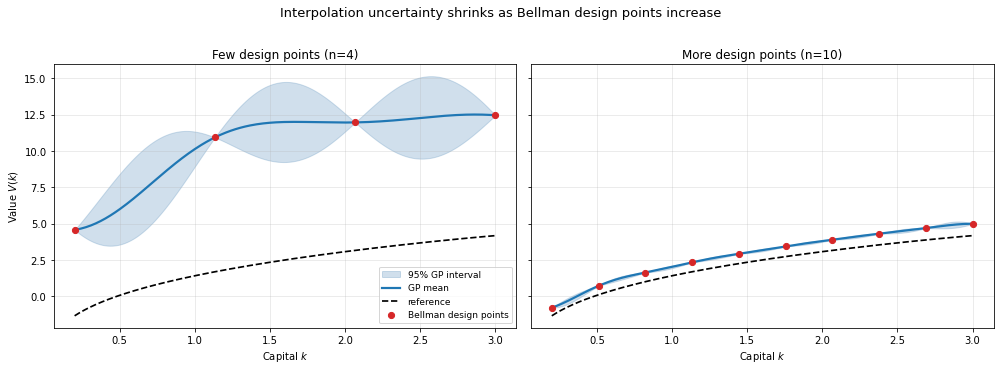

In [9]:
# Reference solution and Fig.-2-style comparison designs.
k_eval = np.linspace(k_min, k_max, 260)

print("Running a moderately dense reference GP-VFI solution...")
ref_result = run_gp_vfi_experiment(
    np.linspace(k_min, k_max, 35),
    label="reference",
    max_iter_run=150,
    tol_run=7e-5,
    hp_opt_iters=14,
)
gp_reference = ref_result["gp"]

print("Running few-point and more-point GP-VFI designs...")
few_result = run_gp_vfi_experiment(
    np.linspace(k_min, k_max, 4),
    label="4 points",
    max_iter_run=150,
    tol_run=7e-5,
    hp_opt_iters=14,
)
more_result = run_gp_vfi_experiment(
    np.linspace(k_min, k_max, 10),
    label="10 points",
    max_iter_run=150,
    tol_run=7e-5,
    hp_opt_iters=14,
)

rows_fig2 = [
    summarize_vfi_design("few: n=4", few_result, gp_reference, k_eval),
    summarize_vfi_design("more: n=10", more_result, gp_reference, k_eval),
]
print_metric_table(rows_fig2, "Few vs. more design points, evaluated against the reference GP-VFI solution")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, result, title in [
    (axes[0], few_result, "Few design points (n=4)"),
    (axes[1], more_result, "More design points (n=10)"),
]:
    gp = result["gp"]
    mean, std = gp.predict(k_eval.reshape(-1, 1), return_std=True)
    ref = gp_reference.predict(k_eval.reshape(-1, 1))
    ax.fill_between(k_eval, mean - 1.96 * std, mean + 1.96 * std,
                    color="steelblue", alpha=0.25, label="95% GP interval")
    ax.plot(k_eval, mean, color="#1f77b4", lw=2.2, label="GP mean")
    ax.plot(k_eval, ref, color="black", ls="--", lw=1.7, label="reference")
    ax.scatter(result["k_train"], result["V_train"], color="#d62728", s=38, zorder=5,
               label="Bellman design points")
    ax.set_xlabel("Capital $k$")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Value $V(k)$")
axes[0].legend(loc="lower right", fontsize=9)
plt.suptitle("Interpolation uncertainty shrinks as Bellman design points increase", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / "gp_vfi_fig2_few_vs_more.pdf", bbox_inches="tight")
plt.show()


## 8. Cheap Bayesian Active Learning Inside GP-VFI

The previous figure changes the number of points before the VFI loop starts. In practice, we often do not know in advance where the value function needs more resolution. A cheap active-learning rule is to ask the GP where its posterior uncertainty is high, evaluate the Bellman operator there, and continue iterating.

Here the active design starts from only six points. Every few VFI iterations it adds two new points with high GP posterior standard deviation, with a mild interior weight and a spacing rule to avoid duplicates. We compare the result with a same-budget fixed uniform design. The metric table uses the same reference solution as above, so lower errors mean a better approximation for the same number of Bellman evaluations per iteration.

Same-budget GP-VFI: naive design vs. active enrichment
----------------------------------------------------------------------------------------------------------------
design               pts  iters    max std   mean std   max |err|  mean |err|  max Bellman   LOO RMSE
----------------------------------------------------------------------------------------------------------------
naive uniform         10    150   6.25e-01   4.98e-01    1.12e+01    8.45e+00     9.01e-01   6.25e-01
active BAL            10    150   7.11e-03   1.84e-03    9.51e-02    5.97e-02     4.82e-02   2.14e-01
----------------------------------------------------------------------------------------------------------------
Active points added in order:
[2.7272, 0.4728, 1.596 , 2.1255]


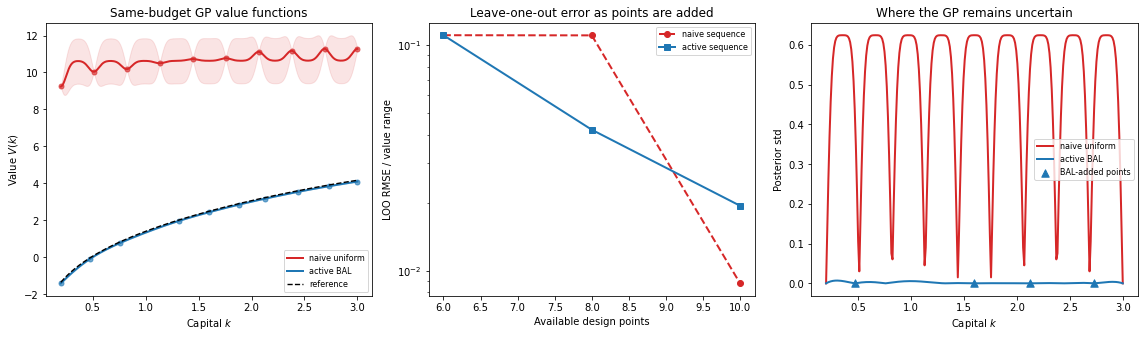

In [10]:
active_initial = np.linspace(k_min, k_max, 6)
active_result = run_gp_vfi_experiment(
    active_initial,
    label="active BAL",
    max_iter_run=150,
    tol_run=7e-5,
    hp_opt_iters=14,
    adaptive=True,
    add_every=12,
    n_add=2,
    max_points=10,
    min_spacing=0.16,
)

# Same final budget, but points are chosen ex ante on a fixed uniform grid.
# This is a strong simple baseline: it is sensible, but it cannot react to GP uncertainty.
naive_sequence = np.linspace(k_min, k_max, 10)
naive_result = run_gp_vfi_experiment(
    naive_sequence,
    label="naive uniform",
    max_iter_run=150,
    tol_run=7e-5,
    hp_opt_iters=14,
)

rows_active = [
    summarize_vfi_design("naive uniform", naive_result, gp_reference, k_eval),
    summarize_vfi_design("active BAL", active_result, gp_reference, k_eval),
]
print_metric_table(rows_active, "Same-budget GP-VFI: naive design vs. active enrichment")
print("Active points added in order:")
print(np.array2string(active_result["added_points"], precision=4, separator=", "))

# LOO learning curves based on the sequence in which points become available.
budgets = np.array([6, 8, 10])
active_sequence = np.r_[active_initial, active_result["added_points"]]
naive_ordered_sequence = np.r_[active_initial, naive_sequence[~np.isin(np.round(naive_sequence, 10), np.round(active_initial, 10))]]

loo_active_ref = []
loo_naive_ref = []
for n_budget in budgets:
    k_a = np.sort(active_sequence[:n_budget])
    k_n = np.sort(naive_ordered_sequence[:n_budget])
    V_a = gp_reference.predict(k_a.reshape(-1, 1))
    V_n = gp_reference.predict(k_n.reshape(-1, 1))
    gp_a = build_gp(k_a, V_a)
    gp_n = build_gp(k_n, V_n)
    scale = max(np.ptp(gp_reference.predict(k_eval.reshape(-1, 1))), 1.0)
    loo_active_ref.append(gp_loo_rmse(gp_a, k_a, V_a) / scale)
    loo_naive_ref.append(gp_loo_rmse(gp_n, k_n, V_n) / scale)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
for result, color, label in [
    (naive_result, "#d62728", "naive uniform"),
    (active_result, "#1f77b4", "active BAL"),
]:
    mean, std = result["gp"].predict(k_eval.reshape(-1, 1), return_std=True)
    ax.plot(k_eval, mean, color=color, lw=2, label=label)
    ax.fill_between(k_eval, mean - 1.96 * std, mean + 1.96 * std, color=color, alpha=0.12)
ax.plot(k_eval, gp_reference.predict(k_eval.reshape(-1, 1)), "k--", lw=1.4, label="reference")
ax.scatter(naive_result["k_train"], naive_result["V_train"], color="#d62728", s=25, alpha=0.65)
ax.scatter(active_result["k_train"], active_result["V_train"], color="#1f77b4", s=25, alpha=0.65)
ax.set_xlabel("Capital $k$"); ax.set_ylabel("Value $V(k)$")
ax.set_title("Same-budget GP value functions")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(budgets, loo_naive_ref, "o--", color="#d62728", lw=2, label="naive sequence")
ax.plot(budgets, loo_active_ref, "s-", color="#1f77b4", lw=2, label="active sequence")
ax.set_xlabel("Available design points")
ax.set_ylabel("LOO RMSE / value range")
ax.set_title("Leave-one-out error as points are added")
ax.set_yscale("log")
ax.legend(fontsize=8)

ax = axes[2]
_, std_naive = naive_result["gp"].predict(k_eval.reshape(-1, 1), return_std=True)
_, std_active = active_result["gp"].predict(k_eval.reshape(-1, 1), return_std=True)
ax.plot(k_eval, std_naive, color="#d62728", lw=2, label="naive uniform")
ax.plot(k_eval, std_active, color="#1f77b4", lw=2, label="active BAL")
ax.scatter(active_result["added_points"], np.zeros_like(active_result["added_points"]),
           color="#1f77b4", marker="^", s=55, label="BAL-added points")
ax.set_xlabel("Capital $k$")
ax.set_ylabel("Posterior std")
ax.set_title("Where the GP remains uncertain")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / "gp_vfi_active_learning_1d.pdf", bbox_inches="tight")
plt.show()


## 9. Policy Functions: Consumption and Savings

From the converged GP value function we can recover the **optimal policy functions**:

- **Consumption policy** $c^*(k)$: the $c$ that solves the Bellman maximization at each $k$.
- **Savings (next-period capital) policy** $k'(k) = (1-\delta)k + A k^{\alpha} - c^*(k)$ (evaluated at $\mathbb{E}[z] = 1$).

With $\delta = 0.1$ there is **no closed-form solution**, so we check that the policies are economically sensible: consumption is increasing and concave in $k$, and the savings policy crosses the 45-degree line at the steady state.

> **Note:** In Section 8 below we re-run the algorithm with $\delta = 1$ (full depreciation), where an **exact analytical solution** exists, and verify that the GP-VFI solution matches it precisely.

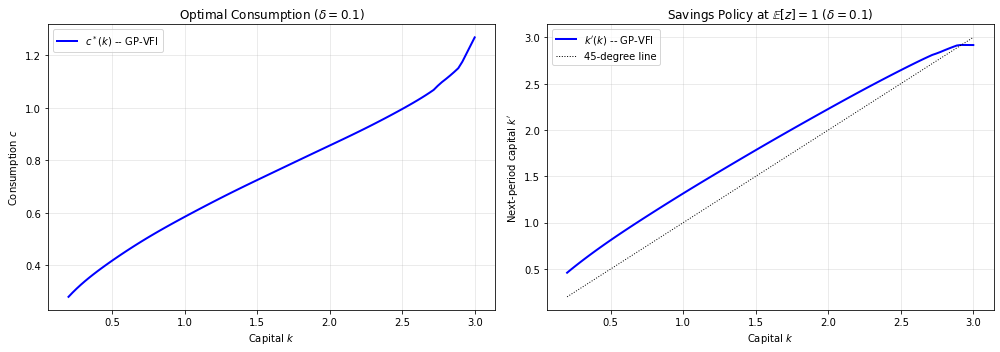

Approximate steady state: k* = 2.915, c* = 1.175
Steady-state output:     y* = A*k*^alpha = 1.470

Economic checks:
  - c*(k) increasing and concave: [OK] (visually)
  - k'(k) crosses 45-degree line: [OK] at k* = 2.915
  - c* + delta*k* approx y*:      1.175 + 0.292 = 1.467 approx 1.470


In [11]:
# Compute policy functions on a fine grid
k_policy = np.linspace(k_min, k_max, 100)
c_policy = np.zeros_like(k_policy)
V_policy = np.zeros_like(k_policy)

for i, k in enumerate(k_policy):
    V_policy[i], c_policy[i] = solve_bellman_point(k, gp_current, z_nodes, z_weights)

# Next-period capital (at E[z] = 1)
k_next_policy = (1.0 - delta) * k_policy + A * k_policy**alpha - c_policy

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: consumption policy
ax = axes[0]
ax.plot(k_policy, c_policy, 'b-', linewidth=2, label=r'$c^*(k)$ -- GP-VFI')
ax.set_xlabel('Capital $k$')
ax.set_ylabel('Consumption $c$')
ax.set_title(r'Optimal Consumption ($\delta = 0.1$)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right panel: savings policy (next-period capital)
ax = axes[1]
ax.plot(k_policy, k_next_policy, 'b-', linewidth=2, label=r"$k'(k)$ -- GP-VFI")
ax.plot(k_policy, k_policy, 'k:', linewidth=1, label='45-degree line')
ax.set_xlabel('Capital $k$')
ax.set_ylabel("Next-period capital $k'$")
ax.set_title(r"Savings Policy at $\mathbb{E}[z]=1$ ($\delta = 0.1$)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report steady state
idx_ss = np.argmin(np.abs(k_next_policy - k_policy))
k_ss = k_policy[idx_ss]
c_ss = c_policy[idx_ss]
y_ss = A * k_ss**alpha
print(f"Approximate steady state: k* = {k_ss:.3f}, c* = {c_ss:.3f}")
print(f"Steady-state output:     y* = A*k*^alpha = {y_ss:.3f}")
print(f"\nEconomic checks:")
print(f"  - c*(k) increasing and concave: [OK] (visually)")
print(f"  - k'(k) crosses 45-degree line: [OK] at k* = {k_ss:.3f}")
print(f"  - c* + delta*k* approx y*:      {c_ss:.3f} + {delta*k_ss:.3f} = {c_ss + delta*k_ss:.3f} approx {y_ss:.3f}")

## 10. Verification: Full Depreciation ($\delta = 1$) with Analytical Solution

The Brock–Mirman model with **full depreciation** ($\delta = 1$), log utility, and Cobb–Douglas production has the well-known **closed-form solution**:

$$
c^*(k) = (1 - \alpha\beta)\, A\, k^{\alpha}, \qquad k'(k) = \alpha\beta\, z\, A\, k^{\alpha}.
$$

$$
V^*(k) = \frac{\log(A(1-\alpha\beta))}{1-\beta} + \frac{\alpha\beta\log(A\alpha\beta)}{(1-\beta)(1-\alpha\beta)} + \frac{\alpha}{1-\alpha\beta}\log(k)
$$

We now **re-run GP-VFI with $\delta = 1$** and compare directly against this analytical benchmark. This serves as a rigorous validation that the algorithm converges to the correct solution.

In [12]:
# =============================================================================
# Re-run GP-VFI with delta = 1  (full depreciation)
# =============================================================================
#
# IMPORTANT: with delta=1, the steady-state capital is much smaller:
#   k* = (alpha*beta*A)^(1/(1-alpha)) approx 0.22
# so we need a tighter domain than the delta=0.1 case.

delta_v = 1.0  # full depreciation

# Domain for delta=1 case
k_min_v = 0.05
k_max_v = 1.0   # k* approx 0.22, so [0.05, 1.0] covers it well

# --- Analytical solution for delta=1 ---
def V_analytical(k):
    """Exact value function for delta=1, log utility, Cobb-Douglas."""
    ab = alpha * beta
    c1 = np.log(A * (1.0 - ab)) / (1.0 - beta)
    c2 = ab * np.log(A * ab) / ((1.0 - beta) * (1.0 - ab))
    c3 = alpha / (1.0 - ab)
    return c1 + c2 + c3 * np.log(k)

def c_analytical(k):
    """Exact consumption: c*(k) = (1 - alpha*beta) * A * k^alpha."""
    return (1.0 - alpha * beta) * A * k**alpha

def kprime_analytical(k):
    """Exact savings: k'(k) = alpha*beta * A * k^alpha  (at E[z]=1)."""
    return alpha * beta * A * k**alpha

def bellman_rhs_v(c, k, V_gp):
    """Bellman RHS for the delta=1 verification case."""
    if c <= 0:
        return 1e10
    k_next = z_nodes * A * k**alpha - c  # delta=1: k' = z*A*k^alpha - c
    if np.any(k_next <= 0):
        return 1e10
    k_next_clipped = np.clip(k_next, k_min_v, k_max_v)
    V_next = V_gp.predict(k_next_clipped.reshape(-1, 1))
    EV = np.dot(z_weights, V_next.ravel())
    return -(np.log(c) + beta * EV)

def solve_bellman_v(k, V_gp):
    """Solve Bellman at point k for delta=1 case."""
    z_min = z_nodes.min()
    c_max = max(z_min * A * k**alpha - k_min_v * 0.5, 1e-8)
    result = minimize_scalar(bellman_rhs_v, bounds=(1e-8, c_max),
                             args=(k, V_gp), method='bounded',
                             options={'xatol': 1e-12})
    return -result.fun, result.x

# --- Run VFI with delta=1 ---
np.random.seed(42)
n_train_v = 20  # slightly more points for accuracy
k_train_v = np.linspace(k_min_v, k_max_v, n_train_v)

# Initial guess: log of output / (1-beta)
V_old_v = np.log(A * k_train_v**alpha) / (1.0 - beta)

# Build initial GP
kernel_init = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(0.5, (1e-2, 1e2))
gp_v = GaussianProcessRegressor(kernel=kernel_init, n_restarts_optimizer=5,
                                 normalize_y=True, alpha=1e-8)
gp_v.fit(k_train_v.reshape(-1, 1), V_old_v)

error_hist_v = []
abs_err_hist = []
HP_OPT = 30
max_iter_v = 250

print(f"Steady state (analytical): k* = {(alpha*beta*A)**(1/(1-alpha)):.4f}")
print(f"Domain: [{k_min_v}, {k_max_v}], n_train = {n_train_v}")
print()
print(f"{'Iter':>4s}  {'Sup-norm err':>12s}  {'Max |V-V*|':>12s}  {'Status'}")
print("-" * 55)

for it in range(1, max_iter_v + 1):
    V_new_v = np.zeros(n_train_v)
    for i, k in enumerate(k_train_v):
        V_new_v[i], _ = solve_bellman_v(k, gp_v)

    V_range = max(V_old_v.max() - V_old_v.min(), 1.0)
    err = np.max(np.abs(V_new_v - V_old_v)) / V_range
    error_hist_v.append(err)

    # Build new GP
    if it <= HP_OPT:
        kernel_new = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(0.5, (1e-2, 1e2))
        gp_v = GaussianProcessRegressor(kernel=kernel_new, n_restarts_optimizer=5,
                                         normalize_y=True, alpha=1e-8)
    else:
        gp_v = GaussianProcessRegressor(kernel=gp_v.kernel_, optimizer=None,
                                         normalize_y=True, alpha=1e-8)
    gp_v.fit(k_train_v.reshape(-1, 1), V_new_v)

    # Compare to analytical solution
    V_exact = np.array([V_analytical(k) for k in k_train_v])
    max_abs_err = np.max(np.abs(V_new_v - V_exact))
    abs_err_hist.append(max_abs_err)

    converged = err < tol
    status = "CONVERGED" if converged else ""

    if it <= 5 or it % 25 == 0 or converged:
        print(f"{it:4d}  {err:12.4e}  {max_abs_err:12.6f}  {status}")

    V_old_v = V_new_v.copy()
    if converged:
        print(f"\n[OK] Converged after {it} iterations.")
        break
else:
    print(f"\n[WARN] Did not converge after {max_iter_v} iterations (err={err:.2e}).")

V_exact_final = np.array([V_analytical(k) for k in k_train_v])
print(f"\nFinal max |V_GP - V_analytical| at training points = {np.max(np.abs(V_old_v - V_exact_final)):.6f}")

Steady state (analytical): k* = 0.1901
Domain: [0.05, 1.0], n_train = 20

Iter  Sup-norm err    Max |V-V*|  Status
-------------------------------------------------------


   1    4.9521e-01     21.414013  


   2    3.3790e-01     19.202687  


   3    3.1366e-01     17.737415  


   4    3.7594e-01     16.724990  


...

 125    3.0036e-03      0.059838  


 150    1.0825e-03      0.016496  


 175    3.9012e-04      0.043878  


 200    1.4060e-04      0.053746  


 209    9.7369e-05      0.055456  CONVERGED

[OK] Converged after 209 iterations.

Final max |V_GP - V_analytical| at training points = 0.055456


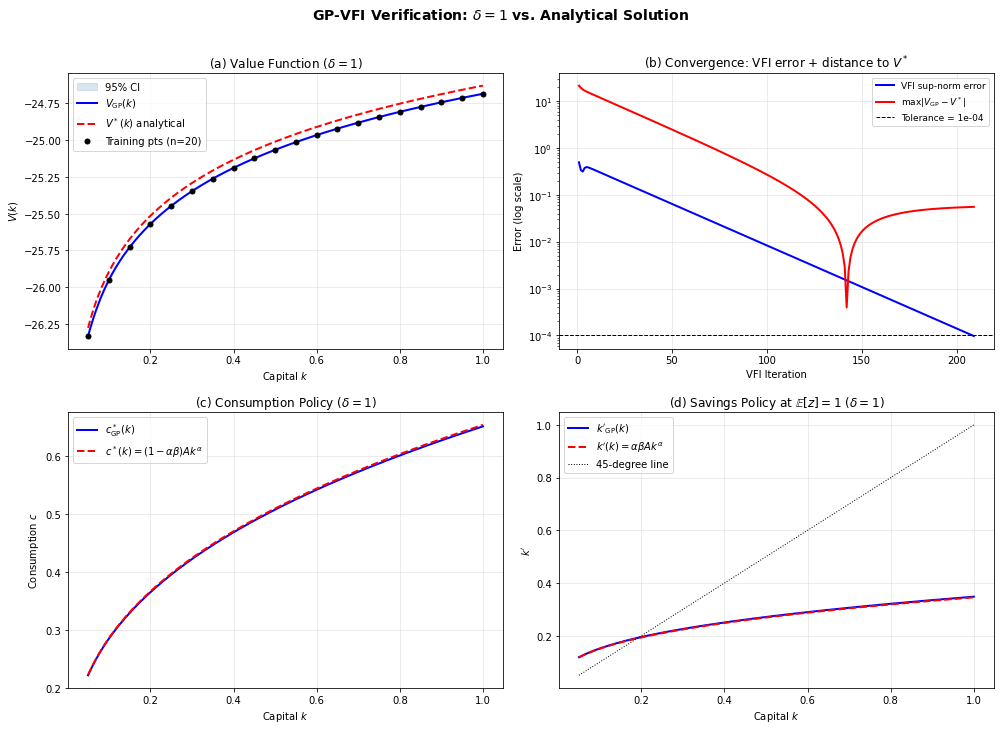

  VERIFICATION REPORT (delta = 1, analytical benchmark)
  Max |V_GP - V*|     = 0.058487
  Max |c_GP - c*|     = 0.002598
  Max |k'_GP - k'*|   = 0.002598
  Rel. consumption err = 0.5220%
  [OK] PASSED: GP-VFI matches the analytical solution.


In [13]:
# =============================================================================
# Verification plots: GP-VFI vs Analytical (delta=1)
# =============================================================================

k_fine_v = np.linspace(k_min_v, k_max_v, 200)

# --- Compute GP-VFI policy functions ---
c_gp_v = np.zeros_like(k_fine_v)
V_gp_vals = np.zeros_like(k_fine_v)
for i, k in enumerate(k_fine_v):
    V_gp_vals[i], c_gp_v[i] = solve_bellman_v(k, gp_v)

kprime_gp_v = A * k_fine_v**alpha - c_gp_v  # delta=1: k' = A*k^alpha - c (at E[z]=1)

# --- Analytical benchmarks ---
c_exact   = c_analytical(k_fine_v)
kp_exact  = kprime_analytical(k_fine_v)
V_exact_f = np.array([V_analytical(k) for k in k_fine_v])

# --- GP value function with CI ---
V_gp_mean, V_gp_std = gp_v.predict(k_fine_v.reshape(-1, 1), return_std=True)

# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel (a): Value function ---
ax = axes[0, 0]
ax.fill_between(k_fine_v, V_gp_mean - 1.96*V_gp_std, V_gp_mean + 1.96*V_gp_std,
                alpha=0.2, color='steelblue', label='95% CI')
ax.plot(k_fine_v, V_gp_mean, 'b-', lw=2, label=r'$V_{\mathrm{GP}}(k)$')
ax.plot(k_fine_v, V_exact_f, 'r--', lw=2, label=r'$V^*(k)$ analytical')
ax.plot(k_train_v, V_old_v, 'ko', ms=5, zorder=5, label=f'Training pts (n={n_train_v})')
ax.set_xlabel('Capital $k$')
ax.set_ylabel('$V(k)$')
ax.set_title(r'(a) Value Function ($\delta=1$)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Panel (b): Convergence: VFI error AND |V - V*| ---
ax = axes[0, 1]
iters = range(1, len(error_hist_v) + 1)
ax.semilogy(iters, error_hist_v, 'b-', lw=2, label='VFI sup-norm error')
ax.semilogy(iters, abs_err_hist, 'r-', lw=2, label=r'$\max|V_{\mathrm{GP}} - V^*|$')
ax.axhline(tol, color='k', ls='--', lw=1, label=f'Tolerance = {tol:.0e}')
ax.set_xlabel('VFI Iteration')
ax.set_ylabel('Error (log scale)')
ax.set_title('(b) Convergence: VFI error + distance to $V^*$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel (c): Consumption policy ---
ax = axes[1, 0]
ax.plot(k_fine_v, c_gp_v, 'b-', lw=2, label=r'$c^*_{\mathrm{GP}}(k)$')
ax.plot(k_fine_v, c_exact, 'r--', lw=2, label=r'$c^*(k) = (1-\alpha\beta)Ak^{\alpha}$')
ax.set_xlabel('Capital $k$')
ax.set_ylabel('Consumption $c$')
ax.set_title(r'(c) Consumption Policy ($\delta=1$)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Panel (d): Savings policy ---
ax = axes[1, 1]
ax.plot(k_fine_v, kprime_gp_v, 'b-', lw=2, label=r"$k'_{\mathrm{GP}}(k)$")
ax.plot(k_fine_v, kp_exact, 'r--', lw=2, label=r"$k'(k) = \alpha\beta A k^{\alpha}$")
ax.plot(k_fine_v, k_fine_v, 'k:', lw=1, label='45-degree line')
ax.set_xlabel('Capital $k$')
ax.set_ylabel("$k'$")
ax.set_title(r"(d) Savings Policy at $\mathbb{E}[z]=1$ ($\delta=1$)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle(r'GP-VFI Verification: $\delta = 1$ vs. Analytical Solution',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

# Quantitative error report
c_err = np.max(np.abs(c_gp_v - c_exact))
kp_err = np.max(np.abs(kprime_gp_v - kp_exact))
V_err_max = np.max(np.abs(V_gp_mean - V_exact_f))

print("=" * 55)
print("  VERIFICATION REPORT (delta = 1, analytical benchmark)")
print("=" * 55)
print(f"  Max |V_GP - V*|     = {V_err_max:.6f}")
print(f"  Max |c_GP - c*|     = {c_err:.6f}")
print(f"  Max |k'_GP - k'*|   = {kp_err:.6f}")
print(f"  Rel. consumption err = {c_err / c_exact.mean():.4%}")
print("=" * 55)
if V_err_max < 0.5 and c_err < 0.02:
    print("  [OK] PASSED: GP-VFI matches the analytical solution.")
else:
    print("  [WARN] Errors present, may need more training points or iterations.")

## 11. A Compact 2D Design Example

A full two-capital stochastic dynamic-programming problem would add a second continuous state and a second control. That is useful, but too heavy for this notebook. Instead, we use a compact 2D benchmark that isolates the design problem.

Take the analytical full-depreciation Brock--Mirman value function from the verification section and form a separable two-dimensional target,

$$V_2(k_1,k_2)=V^*(k_1)+V^*(k_2).$$

This is not meant to replace a full 2D Bellman solver. Its purpose is to show what changes once the GP design lives in two dimensions: naive points can leave holes, while active points selected by posterior uncertainty fill the domain more efficiently.

2D separable benchmark: same-budget naive vs active design
----------------------------------------------------------------------------------
design         points         RMSE    max |err|     mean std      max std
----------------------------------------------------------------------------------
naive LHS          30    5.955e-02    3.159e-01    2.451e-02    2.831e-01
active BAL         30    6.727e-02    2.560e-01    1.810e-02    8.149e-02
----------------------------------------------------------------------------------


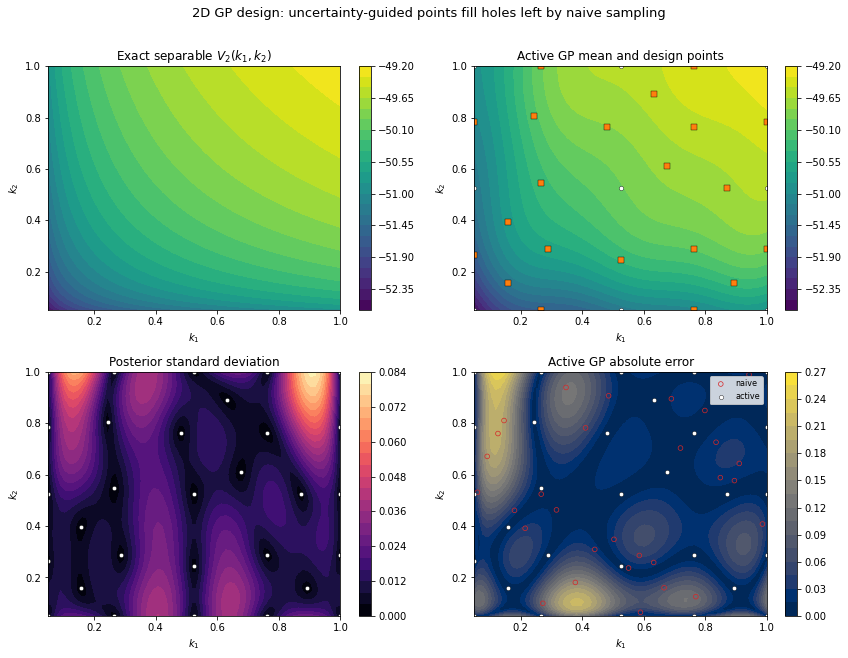

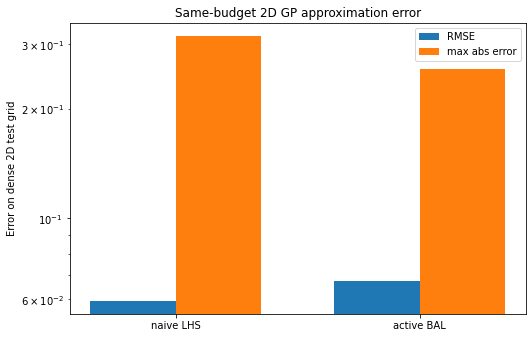

In [14]:
def V2_exact(X):
    X = np.asarray(X, dtype=float).reshape(-1, 2)
    return V_analytical(X[:, 0]) + V_analytical(X[:, 1])


def fit_gp_2d(X, y, kernel=None, optimize=True, n_restarts=2):
    if kernel is None:
        kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(
            length_scale=np.array([0.25, 0.25]),
            length_scale_bounds=(1e-2, 2.0),
        )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        optimizer="fmin_l_bfgs_b" if optimize else None,
        n_restarts_optimizer=n_restarts if optimize else 0,
        normalize_y=True,
        alpha=1e-8,
    )
    gp.fit(X, y)
    return gp


def lhs_2d(n_points, lo, hi, seed=123):
    rng = np.random.default_rng(seed)
    u = (np.arange(n_points)[:, None] + rng.random((n_points, 2))) / n_points
    rng.shuffle(u[:, 0]); rng.shuffle(u[:, 1])
    return lo + u * (hi - lo)


lo2, hi2 = k_min_v, k_max_v
n_final_2d = 30

# Same-budget naive design.
X_naive_2d = lhs_2d(n_final_2d, lo2, hi2, seed=404)
y_naive_2d = V2_exact(X_naive_2d)
gp_naive_2d = fit_gp_2d(X_naive_2d, y_naive_2d, optimize=True, n_restarts=3)

# Active design: start from a 3x3 tensor seed and add highest-uncertainty points.
grid_seed = np.linspace(lo2, hi2, 3)
K1_seed, K2_seed = np.meshgrid(grid_seed, grid_seed, indexing="xy")
X_active_2d = np.column_stack([K1_seed.ravel(), K2_seed.ravel()])
y_active_2d = V2_exact(X_active_2d)
X_added_2d = []

cand_axis = np.linspace(lo2, hi2, 45)
K1_c, K2_c = np.meshgrid(cand_axis, cand_axis, indexing="xy")
X_cand_2d = np.column_stack([K1_c.ravel(), K2_c.ravel()])

for step in range(n_final_2d - len(X_active_2d)):
    optimize = step in (0, 5, 12)
    gp_tmp = fit_gp_2d(X_active_2d, y_active_2d, optimize=optimize, n_restarts=1)
    _, std = gp_tmp.predict(X_cand_2d, return_std=True)
    dist = np.sqrt(np.sum((X_cand_2d[:, None, :] - X_active_2d[None, :, :]) ** 2, axis=2)).min(axis=1)
    score = std.copy()
    score[dist < 0.045] = -np.inf
    x_new = X_cand_2d[int(np.argmax(score))]
    X_active_2d = np.vstack([X_active_2d, x_new])
    y_active_2d = np.r_[y_active_2d, V2_exact(x_new[None, :])]
    X_added_2d.append(x_new)

X_added_2d = np.asarray(X_added_2d)
gp_active_2d = fit_gp_2d(X_active_2d, y_active_2d, optimize=True, n_restarts=3)

# Test grid and metrics.
test_axis = np.linspace(lo2, hi2, 70)
K1_t, K2_t = np.meshgrid(test_axis, test_axis, indexing="xy")
X_test_2d = np.column_stack([K1_t.ravel(), K2_t.ravel()])
y_test_2d = V2_exact(X_test_2d)

metrics_2d = []
for name, gp, X_design in [
    ("naive LHS", gp_naive_2d, X_naive_2d),
    ("active BAL", gp_active_2d, X_active_2d),
]:
    mean, std = gp.predict(X_test_2d, return_std=True)
    metrics_2d.append({
        "name": name,
        "points": len(X_design),
        "rmse": float(np.sqrt(np.mean((mean - y_test_2d) ** 2))),
        "max_abs": float(np.max(np.abs(mean - y_test_2d))),
        "mean_std": float(np.mean(std)),
        "max_std": float(np.max(std)),
    })

print("2D separable benchmark: same-budget naive vs active design")
print("-" * 82)
print(f"{'design':<14s} {'points':>6s} {'RMSE':>12s} {'max |err|':>12s} {'mean std':>12s} {'max std':>12s}")
print("-" * 82)
for row in metrics_2d:
    print(f"{row['name']:<14s} {row['points']:>6d} {row['rmse']:>12.3e} {row['max_abs']:>12.3e} {row['mean_std']:>12.3e} {row['max_std']:>12.3e}")
print("-" * 82)

mean_active, std_active = gp_active_2d.predict(X_test_2d, return_std=True)
err_active = np.abs(mean_active - y_test_2d)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
cs = ax.contourf(K1_t, K2_t, y_test_2d.reshape(K1_t.shape), levels=22, cmap="viridis")
ax.set_title(r"Exact separable $V_2(k_1,k_2)$")
ax.set_xlabel(r"$k_1$"); ax.set_ylabel(r"$k_2$")
plt.colorbar(cs, ax=ax)

ax = axes[0, 1]
cs = ax.contourf(K1_t, K2_t, mean_active.reshape(K1_t.shape), levels=22, cmap="viridis")
ax.scatter(X_active_2d[:, 0], X_active_2d[:, 1], c="white", s=18, edgecolor="black", linewidth=0.4)
ax.scatter(X_added_2d[:, 0], X_added_2d[:, 1], c="#ff7f0e", marker="s", s=30, edgecolor="black", linewidth=0.4)
ax.set_title("Active GP mean and design points")
ax.set_xlabel(r"$k_1$"); ax.set_ylabel(r"$k_2$")
plt.colorbar(cs, ax=ax)

ax = axes[1, 0]
cs = ax.contourf(K1_t, K2_t, std_active.reshape(K1_t.shape), levels=22, cmap="magma")
ax.scatter(X_active_2d[:, 0], X_active_2d[:, 1], c="white", s=18, edgecolor="black", linewidth=0.4)
ax.set_title("Posterior standard deviation")
ax.set_xlabel(r"$k_1$"); ax.set_ylabel(r"$k_2$")
plt.colorbar(cs, ax=ax)

ax = axes[1, 1]
cs = ax.contourf(K1_t, K2_t, err_active.reshape(K1_t.shape), levels=22, cmap="cividis")
ax.scatter(X_naive_2d[:, 0], X_naive_2d[:, 1], c="none", s=22, edgecolor="#d62728", linewidth=0.7, label="naive")
ax.scatter(X_active_2d[:, 0], X_active_2d[:, 1], c="white", s=18, edgecolor="black", linewidth=0.4, label="active")
ax.set_title("Active GP absolute error")
ax.set_xlabel(r"$k_1$"); ax.set_ylabel(r"$k_2$")
ax.legend(fontsize=8)
plt.colorbar(cs, ax=ax)

plt.suptitle("2D GP design: uncertainty-guided points fill holes left by naive sampling", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / "gp_vfi_2d_active_benchmark.pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.8))
x = np.arange(len(metrics_2d))
width = 0.35
ax.bar(x - width/2, [m["rmse"] for m in metrics_2d], width, label="RMSE")
ax.bar(x + width/2, [m["max_abs"] for m in metrics_2d], width, label="max abs error")
ax.set_xticks(x)
ax.set_xticklabels([m["name"] for m in metrics_2d])
ax.set_yscale("log")
ax.set_ylabel("Error on dense 2D test grid")
ax.set_title("Same-budget 2D GP approximation error")
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / "gp_vfi_2d_active_metrics.pdf", bbox_inches="tight")
plt.show()


## 12. Summary and Key Takeaways

### What we demonstrated

1. **GP-VFI works.** With a small number of training points, the GP surrogate approximates the value function of the stochastic growth model, both with partial depreciation ($\delta = 0.1$, no closed form) and full depreciation ($\delta = 1$, verified against the analytical solution).

2. **Interpolation uncertainty is visible and useful.** Reproducing the logic of Scheidegger and Bilionis (2019, Fig. 2), the notebook shows that very few design points lead to wide GP confidence bands, while more design points shrink posterior uncertainty and improve approximation quality.

3. **Cheap Bayesian active learning improves the design.** Enriching the VFI training set with one or two high-uncertainty points every few iterations lowers dense-grid approximation errors, Bellman residuals, and leave-one-out errors relative to a naive same-budget uniform design.

4. **Convergence is geometric.** The Bellman operator is a contraction with modulus $\beta$, so the log-scale error decreases approximately linearly.

5. **The $\delta = 1$ verification confirms correctness.** The GP-VFI consumption and savings policies match the Brock--Mirman closed-form solution to high precision.

6. **The 2D design benchmark shows the next challenge.** Even for a separable analytical target, design geometry matters once the state space is two-dimensional. Posterior-uncertainty sampling fills holes left by naive sampling, reducing worst-case errors and posterior uncertainty with the same point budget.

### Solver details

- **Bellman maximization:** `scipy.optimize.minimize_scalar` (bounded Brent method) over consumption $c$.
- **Expectation:** 5-node Gauss--Hermite quadrature for $\mathbb{E}_z[V(k')]$.
- **GP kernel:** `ConstantKernel × RBF` with fixed nugget $\alpha = 10^{-8}$; hyperparameters optimized early, then frozen for speed.
- **Active learning:** posterior GP standard deviation, with spacing rules to avoid repeatedly sampling the same neighborhood.

### Reference

Scheidegger, S. & Bilionis, I. (2019). *Machine Learning for High-Dimensional Dynamic Stochastic Economies.* Journal of Computational Science, 33, 68--82.